# Notebook 04 — Kỹ thuật Đặc trưng (Feature Engineering)
**Đề tài 7 — Nhóm 13 | 2025–2026**

---
Tạo các đặc trưng mới từ dữ liệu thô:
- Đặc trưng tương tác (interaction features)
- Đặc trưng đa thức (polynomial)
- Thống kê tổng hợp theo cây/quốc gia
- Điểm sinh trưởng (grow score) dựa trên kiến thức nông nghiệp
- Chỉ số stress (nhiệt, hạn, lũ)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
from sklearn.preprocessing import StandardScaler

PROC = Path("../data/processed")
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / "crop_yield_processed.csv")
print(f"Dữ liệu đầu vào: {df.shape}")
df.head(3)

Dữ liệu đầu vào: (28242, 18)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_enc,Item_enc,yield_cat,rain_cat,temp_cat,pest_cat,log_yield,log_pesticides,log_rain,year_norm,decade
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37,0,1,Medium,Wet,Cold,LowPest,10.508186,4.804021,7.303843,0.0,1990
1,Albania,Potatoes,1990,66667.0,1485.0,121.0,16.37,0,3,Medium,Wet,Cold,LowPest,11.107480,4.804021,7.303843,0.0,1990
2,Albania,"Rice, paddy",1990,23333.0,1485.0,121.0,16.37,0,4,Low,Wet,Cold,LowPest,10.057667,4.804021,7.303843,0.0,1990


## 1. Đặc trưng Tương tác (Interaction Features)

In [2]:
# Tương tác giữa các biến khí hậu
df["rain_x_temp"]    = df["average_rain_fall_mm_per_year"] * df["avg_temp"]
df["pest_x_rain"]    = df["log_pesticides"] * df["log_rain"]
df["pest_x_temp"]    = df["log_pesticides"] * df["avg_temp"]
df["rain_per_temp"]  = df["average_rain_fall_mm_per_year"] / (df["avg_temp"].abs() + 1)
df["temp_rain_ratio"]= df["avg_temp"] / (np.log1p(df["average_rain_fall_mm_per_year"]) + 1)
print("Đã thêm 5 đặc trưng tương tác: rain_x_temp, pest_x_rain, pest_x_temp, rain_per_temp, temp_rain_ratio")

Đã thêm 5 đặc trưng tương tác: rain_x_temp, pest_x_rain, pest_x_temp, rain_per_temp, temp_rain_ratio


## 2. Đặc trưng Đa thức (Polynomial)

In [3]:
df["rain_sq"]  = df["average_rain_fall_mm_per_year"] ** 2
df["temp_sq"]  = df["avg_temp"] ** 2
df["pest_sq"]  = df["log_pesticides"] ** 2
df["rain_cb"]  = df["average_rain_fall_mm_per_year"] ** 0.5   # căn bậc 2
df["temp_abs"] = (df["avg_temp"] - df["avg_temp"].mean()).abs()
print("Đã thêm 5 đặc trưng đa thức: rain_sq, temp_sq, pest_sq, rain_cb, temp_abs")

Đã thêm 5 đặc trưng đa thức: rain_sq, temp_sq, pest_sq, rain_cb, temp_abs


## 3. Thống kê tổng hợp theo Cây & Quốc gia

In [4]:
# Thống kê theo loại cây
for col in ["average_rain_fall_mm_per_year","avg_temp","pesticides_tonnes"]:
    short = col[:4]
    stats = df.groupby("Item")[col].agg(["mean","std"]).rename(
        columns={"mean":f"{short}_crop_mean","std":f"{short}_crop_std"})
    df = df.merge(stats, on="Item", how="left")

# Thống kê theo quốc gia
for col in ["average_rain_fall_mm_per_year","avg_temp"]:
    short = col[:4]
    stats = df.groupby("Area")[col].agg(["mean","std"]).rename(
        columns={"mean":f"{short}_area_mean","std":f"{short}_area_std"})
    df = df.merge(stats, on="Area", how="left")

# Deviation từ mean của crop
df["yield_vs_crop_mean"] = df.groupby("Item")["hg/ha_yield"].transform(
    lambda x: (x - x.mean()) / (x.std() + 1))

print(f"Shape sau khi thêm thống kê tổng hợp: {df.shape}")

Shape sau khi thêm thống kê tổng hợp: (28242, 39)


## 4. Điểm Sinh trưởng Tối ưu (Grow Score)

In [5]:
# Nhiệt độ và lượng mưa tối ưu cho từng loại cây (nguồn: tài liệu nông nghiệp FAO)
CROP_OPT = {
    "Maize":              {"rain": 700,  "temp": 22},
    "Wheat":              {"rain": 450,  "temp": 15},
    "Rice, paddy":        {"rain": 1500, "temp": 27},
    "Soybeans":           {"rain": 600,  "temp": 24},
    "Potatoes":           {"rain": 550,  "temp": 17},
    "Cassava":            {"rain": 1200, "temp": 28},
    "Sorghum":            {"rain": 500,  "temp": 28},
    "Sweet potatoes":     {"rain": 900,  "temp": 25},
    "Plantains and others":{"rain":1800, "temp": 26},
    "Yams":               {"rain": 1200, "temp": 26},
}

def grow_score(row):
    opt = CROP_OPT.get(row["Item"], {"rain": 800, "temp": 22})
    d_rain = abs(row["average_rain_fall_mm_per_year"] - opt["rain"])
    d_temp = abs(row["avg_temp"] - opt["temp"])
    return np.exp(-d_rain/500) * np.exp(-d_temp/8)

df["grow_score"]       = df.apply(grow_score, axis=1)
df["rain_dev_from_opt"]= df.apply(lambda r: abs(r["average_rain_fall_mm_per_year"] - CROP_OPT.get(r["Item"],{"rain":800})["rain"]), axis=1)
df["temp_dev_from_opt"]= df.apply(lambda r: abs(r["avg_temp"] - CROP_OPT.get(r["Item"],{"temp":22})["temp"]), axis=1)
print(f"grow_score range: {df.grow_score.min():.4f} – {df.grow_score.max():.4f}")

grow_score range: 0.0008 – 0.9881


## 5. Chỉ số Stress & Đặc trưng thời gian

In [6]:
# Stress indicators
df["heat_stress"]    = (df["avg_temp"] > 32).astype(int)
df["drought_stress"] = (df["average_rain_fall_mm_per_year"] < 250).astype(int)
df["flood_risk"]     = (df["average_rain_fall_mm_per_year"] > 2500).astype(int)
df["frost_risk"]     = (df["avg_temp"] < 5).astype(int)
df["stress_count"]   = df["heat_stress"] + df["drought_stress"] + df["flood_risk"] + df["frost_risk"]

# Thời gian
df["years_since_1990"] = df["Year"] - 1990
df["is_modern"]        = (df["Year"] >= 2005).astype(int)
df["decade_2000s"]     = (df["decade"] == 2000).astype(int)
df["decade_2010s"]     = (df["decade"] == 2010).astype(int)
df["is_high_yield_crop"]= df["Item"].isin(["Potatoes","Cassava","Sweet potatoes","Yams","Plantains and others"]).astype(int)

print("Đã thêm stress indicators và time features")
print(f"Shape cuối: {df.shape}")

# Liệt kê tất cả đặc trưng
exclude = ["Area","Item","hg/ha_yield","log_yield","yield_cat","rain_cat","temp_cat","pest_cat"]
feature_cols = [c for c in df.columns if c not in exclude]
print(f"\nTổng số đặc trưng: {len(feature_cols)}")
for i in range(0, len(feature_cols), 6): print(" ", feature_cols[i:i+6])

Đã thêm stress indicators và time features
Shape cuối: (28242, 52)

Tổng số đặc trưng: 44
  ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Area_enc', 'Item_enc']
  ['log_pesticides', 'log_rain', 'year_norm', 'decade', 'rain_x_temp', 'pest_x_rain']
  ['pest_x_temp', 'rain_per_temp', 'temp_rain_ratio', 'rain_sq', 'temp_sq', 'pest_sq']
  ['rain_cb', 'temp_abs', 'aver_crop_mean', 'aver_crop_std', 'avg__crop_mean', 'avg__crop_std']
  ['pest_crop_mean', 'pest_crop_std', 'aver_area_mean', 'aver_area_std', 'avg__area_mean', 'avg__area_std']
  ['yield_vs_crop_mean', 'grow_score', 'rain_dev_from_opt', 'temp_dev_from_opt', 'heat_stress', 'drought_stress']
  ['flood_risk', 'frost_risk', 'stress_count', 'years_since_1990', 'is_modern', 'decade_2000s']
  ['decade_2010s', 'is_high_yield_crop']


## 6. Chuẩn hóa & Lưu

In [7]:
# Fill NaN và chuẩn hóa
for c in feature_cols:
    if c in df.columns: df[c] = df[c].fillna(df[c].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols].values)
df_feat = pd.DataFrame(X_scaled, columns=feature_cols)

# Thêm lại biến mục tiêu và phân loại
for col in ["hg/ha_yield","log_yield","Area","Item","Year","Area_enc","Item_enc","yield_cat","rain_cat","temp_cat","pest_cat"]:
    if col in df.columns: df_feat[col] = df[col].values

df_feat.to_csv(Path("../data/processed") / "crop_yield_features.csv", index=False)

import json
scaler_params = {"feature_names": feature_cols, "mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist(),
                 "crop_opt": CROP_OPT}
with open(Path("../data/processed") / "scaler_params.json", "w") as f: json.dump(scaler_params, f, indent=2)
print(f"Saved: crop_yield_features.csv ({df_feat.shape})")
print(f"Saved: scaler_params.json ({len(feature_cols)} features)")

Saved: crop_yield_features.csv ((28242, 52))
Saved: scaler_params.json (44 features)


## 7. Tương quan các đặc trưng mới với Yield

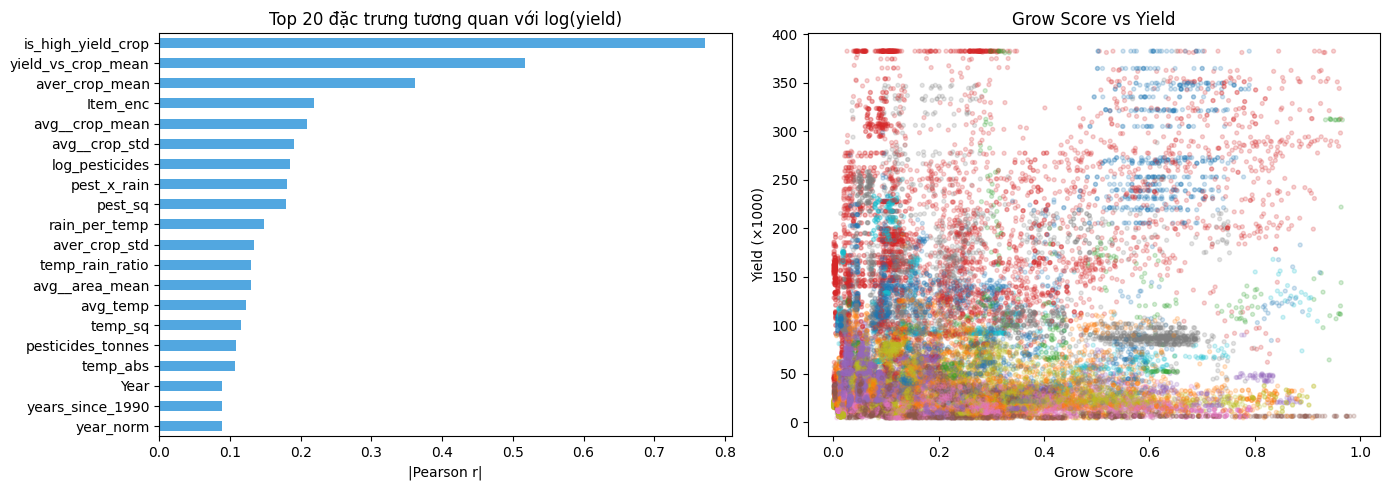

In [8]:
corr_with_yield = df_feat[feature_cols + ["log_yield"]].corr()["log_yield"].drop("log_yield").abs()
top20 = corr_with_yield.sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top20.sort_values().plot(kind="barh", ax=axes[0], color="#3498db", alpha=0.85)
axes[0].set_title("Top 20 đặc trưng tương quan với log(yield)")
axes[0].set_xlabel("|Pearson r|")

axes[1].scatter(df["grow_score"], df["hg/ha_yield"]/1000, alpha=0.2, s=8, c=df["Item_enc"], cmap="tab10")
axes[1].set_title("Grow Score vs Yield"); axes[1].set_xlabel("Grow Score"); axes[1].set_ylabel("Yield (×1000)")

plt.tight_layout()
plt.savefig(OUT / "04_feature_engineering.png", dpi=100, bbox_inches="tight"); plt.show()